# Fitting an Advertising Spend Response Model (Quasi-Newton BFGS)

## Background and Motivation

Understanding how advertising expenditure translates to sales is a classic problem in economics and marketing. Intuitively, advertising exhibits diminishing returns: the first dollars spent yield large gains in sales, but beyond a certain point additional spend has progressively smaller impact. In other words, the relationship between ad spend and sales is concave – initial spending is very effective, and later spending saturates the market. To make informed budgeting decisions, a company would like to model this response curve. In this exercise, we use a real advertising dataset to fit a nonlinear response function that captures saturation effects. By formulating this as an optimization problem, we can apply quasi-Newton methods (like BFGS) to estimate the model parameters. Such a model can then be used to determine the ROI of advertising and to find the spending level beyond which returns diminish.

## Dataset Description

We will use the Advertising dataset from the textbook Introduction to Statistical Learning. This dataset contains data for 200 different markets, including the advertising budgets spent on TV, radio, and newspaper and the corresponding product sales in each market ￼. For simplicity, we focus on one advertising channel (TV) and its effect on sales. The data provides pairs $(\mathbf{x}_i, y_i)$ for $i=1,\dots,200$, where $\mathbf{x}_i \in \mathbb{R}^3$ is the vector of TV, radio, and newspaper advertising budgets in that market (in thousands of dollars) and $y_i$ is the product sales (in thousands of units). Empirical analysis suggests a positive but flattening relationship between $x$ and $y$: initially, increasing TV spend strongly boosts sales, but eventually additional TV ads yield only minor increases. Our goal is to fit a curve that captures this pattern.

## Problem Formulation

Rather than a simple linear model, we choose a nonlinear saturation model for the relationship between advertising spend $x$ and expected sales $f(x)$. A reasonable choice is an exponential diminishing-returns function:
$$
f(\mathbf{x}_i; a, \mathbf{b}) = a \left(1 - e^{- \mathbf{x}_i^\top \mathbf{b}} \right),
$$
where $a$ and $\mathbf{b}$ are parameters to be estimated from the data. Here $a$ represents the asymptotic maximum sales (the plateau value as $x \to \infty$), and $b$ controls the rate of saturation (larger $b$ means the curve rises quickly then saturates early). For very small $x$, $f(x)\approx a b x$ (approximately linear growth), and as $x$ grows large, $f(x)\to a$ (sales approach a ceiling of $a$ units). This form aligns with the idea that the first advertising dollars have the highest impact, and returns diminish with higher spend ￼.

**Objective**: We will fit this model by finding the parameters $a$ and $\mathbf{b}$ that minimize the sum of squared errors between predicted and actual sales. If $y_i$ is the observed sales for market $i$ and $\mathbf{x}_i$ the budgets, our optimization problem is:
$$
\min_{a,\mathbf{b}} \; F(a,\mathbf{b}) = \frac{1}{2}\sum_{i=1}^{200} \big( f(\mathbf{x}_i; a,\mathbf{b}) - y_i \big)^2,
$$
where $f(\mathbf{x}_i; a,\mathbf{b})$ is defined as above. This is an unconstrained nonlinear least-squares problem in two variables. (In principle, we expect $a>0$ and $\mathbf{b}>0$, since negative values would violate the intended meaning.)

The function $F(a,b)$ is differentiable but not globally convex in all parameters (it is generally nonlinear and can have local minima if the model can oscillate, though in practice this particular form is well-behaved for positive $a,b$). There is no closed-form solution, so we must resort to iterative numerical optimization.


In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/master/Notebooks/Data/Advertising.csv"
df = pd.read_csv(url)
df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


## Tasks:

- Apply a quasi-Newton method (BFGS or DFP rank 2 updates) to the problem and derive the detailed steps;

- Implement Newton's method in python (write your own code) and fit to the advertising data, validate and interpret your results.

## Solution: Derivation and Algorithms

Let
$$
r_i(a,\mathbf{b}) = a\left(1-e^{-\mathbf{x}_i^\top\mathbf{b}}\right)-y_i,
\qquad
F(a,\mathbf{b})=\frac12\sum_{i=1}^n r_i^2.
$$

Define
$$
z_i = \mathbf{x}_i^\top\mathbf{b},\quad e_i=e^{-z_i},\quad s_i=1-e_i.
$$
Then for each observation,
$$
\frac{\partial f_i}{\partial a}=s_i,
\qquad
\frac{\partial f_i}{\partial \mathbf{b}}=a e_i\mathbf{x}_i.
$$
Hence the gradient of \(F\) is
$$
\nabla_a F = \sum_i r_i s_i,
\qquad
\nabla_{\mathbf{b}} F = \sum_i r_i\, a e_i\mathbf{x}_i.
$$

Using \(\nabla^2F = \sum_i (J_i^\top J_i + r_i\nabla^2 f_i)\), where \(J_i\) is the Jacobian of \(f_i\),
$$
\frac{\partial^2 f_i}{\partial a^2}=0,
\quad
\frac{\partial^2 f_i}{\partial a\partial\mathbf{b}}=e_i\mathbf{x}_i,
\quad
\frac{\partial^2 f_i}{\partial\mathbf{b}\partial\mathbf{b}^\top}=-a e_i\mathbf{x}_i\mathbf{x}_i^\top.
$$

So Newton's step solves
$$
\theta^{(t+1)} = \theta^{(t)} - \alpha_t H(\theta^{(t)})^{-1}\nabla F(\theta^{(t)}),
$$
with backtracking line search \(\alpha_t\).

For quasi-Newton BFGS (rank-2 update), with \(s_t=\theta_{t+1}-\theta_t\), \(y_t=\nabla F_{t+1}-\nabla F_t\),
$$
B_{t+1}^{-1}=(I-\rho_t s_t y_t^\top)B_t^{-1}(I-\rho_t y_t s_t^\top)+\rho_t s_t s_t^\top,
\quad \rho_t=\frac{1}{y_t^\top s_t}.
$$


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Data (use existing df from previous cell if available)
if 'df' not in globals():
    url = "https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/master/Notebooks/Data/Advertising.csv"
    df = pd.read_csv(url)

# Handle column name capitalization robustly (e.g., Radio vs radio)
colmap = {c.lower(): c for c in df.columns}
needed = ["tv", "radio", "newspaper", "sales"]
missing = [k for k in needed if k not in colmap]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Found columns: {list(df.columns)}")

X = df[[colmap["tv"], colmap["radio"], colmap["newspaper"]]].to_numpy(dtype=float)
y = df[colmap["sales"]].to_numpy(dtype=float)
n, p = X.shape


def model(theta, X):
    a = theta[0]
    b = theta[1:]
    z = X @ b
    pred = a * (1.0 - np.exp(-z))
    return pred, z


def objective(theta, X, y):
    pred, _ = model(theta, X)
    r = pred - y
    return 0.5 * np.dot(r, r)


def grad_hess(theta, X, y):
    a = theta[0]
    pred, z = model(theta, X)

    e = np.exp(-z)
    s = 1.0 - e
    r = pred - y

    # Jacobian blocks for each i
    v = (a * e)[:, None] * X  # d f_i / d b

    # Gradient
    g_a = np.dot(r, s)
    g_b = np.sum(r[:, None] * v, axis=0)
    g = np.concatenate(([g_a], g_b))

    # Hessian (exact)
    H_aa = np.dot(s, s)
    H_ab = np.sum(s[:, None] * v + (r * e)[:, None] * X, axis=0)
    weights = -a * r * e
    H_bb = v.T @ v + (X * weights[:, None]).T @ X

    H = np.empty((p + 1, p + 1))
    H[0, 0] = H_aa
    H[0, 1:] = H_ab
    H[1:, 0] = H_ab
    H[1:, 1:] = H_bb
    return g, H


def gradient(theta, X, y):
    return grad_hess(theta, X, y)[0]


def backtracking(theta, direction, g, f, X, y, alpha=1.0, c=1e-4, beta=0.5, min_alpha=1e-8):
    gd = float(np.dot(g, direction))
    while alpha >= min_alpha:
        cand = theta + alpha * direction
        # Keep parameters positive (model interpretation)
        if np.all(cand > 1e-10):
            f_new = objective(cand, X, y)
            if f_new <= f + c * alpha * gd:
                return cand, f_new, alpha
        alpha *= beta
    return None, f, 0.0


def newton_method(theta0, X, y, tol=1e-8, max_iter=100):
    theta = theta0.astype(float).copy()
    hist = []
    I = np.eye(theta.size)

    for k in range(max_iter):
        f = objective(theta, X, y)
        g, H = grad_hess(theta, X, y)
        gnorm = np.linalg.norm(g)
        hist.append((k, f, gnorm))

        if gnorm < tol:
            break

        # Modified Newton: add damping if Hessian is ill-conditioned/non-descent
        lam = 1e-10
        direction = None
        for _ in range(14):
            try:
                p = np.linalg.solve(H + lam * I, g)
            except np.linalg.LinAlgError:
                lam = max(1e-8, 10.0 * lam)
                continue
            if np.dot(g, p) > 0:  # ensures d = -p is descent
                direction = -p
                break
            lam = max(1e-8, 10.0 * lam)

        if direction is None:
            break

        theta_new, f_new, alpha = backtracking(theta, direction, g, f, X, y)
        if theta_new is None:
            break
        theta = theta_new

    return theta, np.array(hist, dtype=float)


def objective_u(u, X, y):
    # Reparameterize theta = exp(u) so positivity is automatic.
    # Guard against extreme overflow regions in line search.
    if np.any(u > 20) or np.any(u < -30):
        return np.inf
    theta = np.exp(u)
    f = objective(theta, X, y)
    return f if np.isfinite(f) else np.inf


def gradient_u(u, X, y):
    theta = np.exp(np.clip(u, -30, 20))
    g_theta = gradient(theta, X, y)
    # Chain rule: dF/du_j = dF/dtheta_j * dtheta_j/du_j = g_theta_j * theta_j
    return g_theta * theta


def _bfgs_single_log(theta_start, X, y, tol=1e-8, max_iter=400):
    # Run BFGS in u-space for numerical stability and positivity constraints.
    u = np.log(np.clip(theta_start.astype(float), 1e-12, None))
    m = u.size
    Hinv = np.eye(m)
    hist = []

    for k in range(max_iter):
        theta = np.exp(np.clip(u, -30, 20))
        f = objective(theta, X, y)
        g = gradient_u(u, X, y)
        gnorm = np.linalg.norm(g)
        hist.append((k, f, gnorm))

        if gnorm < tol:
            break

        d = -Hinv @ g
        if np.dot(g, d) >= 0:  # safeguard to maintain descent
            d = -g
            Hinv = np.eye(m)

        # Armijo backtracking in unconstrained u-space
        alpha = 1.0
        c = 1e-4
        beta = 0.5
        gd = float(np.dot(g, d))
        accepted = False
        while alpha >= 1e-12:
            u_new = u + alpha * d
            f_new = objective_u(u_new, X, y)
            if np.isfinite(f_new) and f_new <= f + c * alpha * gd:
                accepted = True
                break
            alpha *= beta

        if not accepted:
            break

        # If objective improvement is negligible, treat as converged.
        if abs(f_new - f) <= 1e-12 * (1.0 + abs(f)):
            u = u_new
            break

        g_new = gradient_u(u_new, X, y)
        s = u_new - u
        yk = g_new - g
        sy = float(np.dot(s, yk))

        if sy > 1e-12:
            rho = 1.0 / sy
            I = np.eye(m)
            V = I - rho * np.outer(s, yk)
            Hinv = V @ Hinv @ V.T + rho * np.outer(s, s)
        else:
            Hinv = np.eye(m)

        u = u_new

    theta_final = np.exp(np.clip(u, -30, 20))
    return theta_final, np.array(hist, dtype=float)


def bfgs_method(theta0, X, y, tol=1e-8, max_iter=400, n_random_starts=8, seed=0):
    # This objective is nonconvex; use deterministic multi-start and keep the best run.
    rng = np.random.default_rng(seed)
    starts = [
        theta0,
        np.concatenate(([y.max()], np.full(X.shape[1], 0.005))),
        np.concatenate(([2.0 * y.max()], np.full(X.shape[1], 0.001))),
        np.concatenate(([0.8 * y.max()], np.array([0.002, 0.004, 0.001]))),
    ]
    for _ in range(n_random_starts):
        jitter = np.exp(rng.normal(0.0, 1.0, size=theta0.size))
        starts.append(np.maximum(theta0 * jitter, 1e-10))

    best_theta = None
    best_hist = None
    best_f = np.inf

    for s0 in starts:
        th, hist = _bfgs_single_log(s0, X, y, tol=tol, max_iter=max_iter)
        f = objective(th, X, y)
        if np.isfinite(f) and f < best_f:
            best_f = f
            best_theta = th
            best_hist = hist

    return best_theta, best_hist



Matplotlib is building the font cache; this may take a moment.


In [3]:

def rmse_r2(theta, X, y):
    pred, _ = model(theta, X)
    resid = y - pred
    rmse = np.sqrt(np.mean(resid ** 2))
    r2 = 1.0 - np.sum(resid ** 2) / np.sum((y - y.mean()) ** 2)
    return rmse, r2



In [4]:

# Initialization: a near max sales, small positive b's
theta0 = np.concatenate(([1.10 * y.max()], np.full(p, 0.01)))

theta_newton, hist_newton = newton_method(theta0, X, y, tol=1e-8, max_iter=120)
theta_bfgs, hist_bfgs = bfgs_method(theta0, X, y, tol=1e-5, max_iter=500)

# Validation with SciPy quasi-Newton (L-BFGS-B with positivity bounds)
bounds = [(1e-10, None)] * (p + 1)
scipy_res = minimize(
    fun=lambda th: objective(th, X, y),
    x0=theta0,
    jac=lambda th: gradient(th, X, y),
    method="L-BFGS-B",
    bounds=bounds,
    options={"maxiter": 1000, "ftol": 1e-12},
)

theta_scipy = scipy_res.x

# Compare methods
rows = []
for name, th, hist in [
    ("Newton (custom)", theta_newton, hist_newton),
    ("BFGS (custom)", theta_bfgs, hist_bfgs),
]:
    rmse, r2 = rmse_r2(th, X, y)
    rows.append(
        {
            "method": name,
            "a": th[0],
            "b_TV": th[1],
            "b_radio": th[2],
            "b_news": th[3],
            "objective": objective(th, X, y),
            "RMSE": rmse,
            "R2": r2,
            "iters": int(hist[-1, 0]) + 1,
            "grad_norm": hist[-1, 2],
        }
    )

rmse_s, r2_s = rmse_r2(theta_scipy, X, y)
rows.append(
    {
        "method": "SciPy L-BFGS-B",
        "a": theta_scipy[0],
        "b_TV": theta_scipy[1],
        "b_radio": theta_scipy[2],
        "b_news": theta_scipy[3],
        "objective": objective(theta_scipy, X, y),
        "RMSE": rmse_s,
        "R2": r2_s,
        "iters": int(scipy_res.nit),
        "grad_norm": np.linalg.norm(scipy_res.jac),
    }
)

summary = pd.DataFrame(rows)
summary


,method,a,b_TV,b_radio,b_news,objective,RMSE,R2,iters,grad_norm
0,Newton (custom),70.027079,0.000904,0.003618,0.000223,376.01987,1.939123,0.861174,32,1.678722e-09
1,BFGS (custom),70.027080,0.000904,0.003618,0.000223,376.01987,1.939123,0.861174,35,1.490675e-03
2,SciPy L-BFGS-B,70.026593,0.000904,0.003618,0.000223,376.01987,1.939123,0.861174,48,1.370088e+00


In [5]:
# Pick the best fit by objective value
best_row = summary.loc[summary["objective"].idxmin()]
best_method = best_row["method"]
if best_method == "Newton (custom)":
    best_theta = theta_newton
elif best_method == "BFGS (custom)":
    best_theta = theta_bfgs
else:
    best_theta = theta_scipy

pred_best, _ = model(best_theta, X)

# Useful interpretation numbers
half_saturation = np.log(2.0) / best_theta[1:]
interpret = pd.DataFrame(
    {
        "channel": ["TV", "radio", "newspaper"],
        "b_j": best_theta[1:],
        "half_saturation_x_j": half_saturation,
    }
)

print("Best method:", best_method)
print("Estimated asymptotic sales a (thousand units):", round(float(best_theta[0]), 4))
print("\nHalf-saturation spend x_j = ln(2)/b_j (in thousand dollars):")
interpret


Best method: Newton (custom)
Estimated asymptotic sales a (thousand units): 70.0271

Half-saturation spend x_j = ln(2)/b_j (in thousand dollars):


,channel,b_j,half_saturation_x_j
0,TV,0.000904,766.926985
1,radio,0.003618,191.559317
2,newspaper,0.000223,3102.701764


## Interpretation

- The fitted \(a\) is the estimated sales plateau (thousand units) as total ad pressure becomes very large.
- Each \(b_j\) is a saturation-rate parameter for channel \(j\): larger \(b_j\) means faster diminishing returns for that channel.
- The quantity \(x_{1/2,j}=\log(2)/b_j\) is the spend level where channel \(j\) (holding others fixed) reaches about 50% of its own saturation effect.
- Compare objective, RMSE, and \(R^2\) across Newton, custom BFGS, and SciPy to validate correctness and numerical stability.


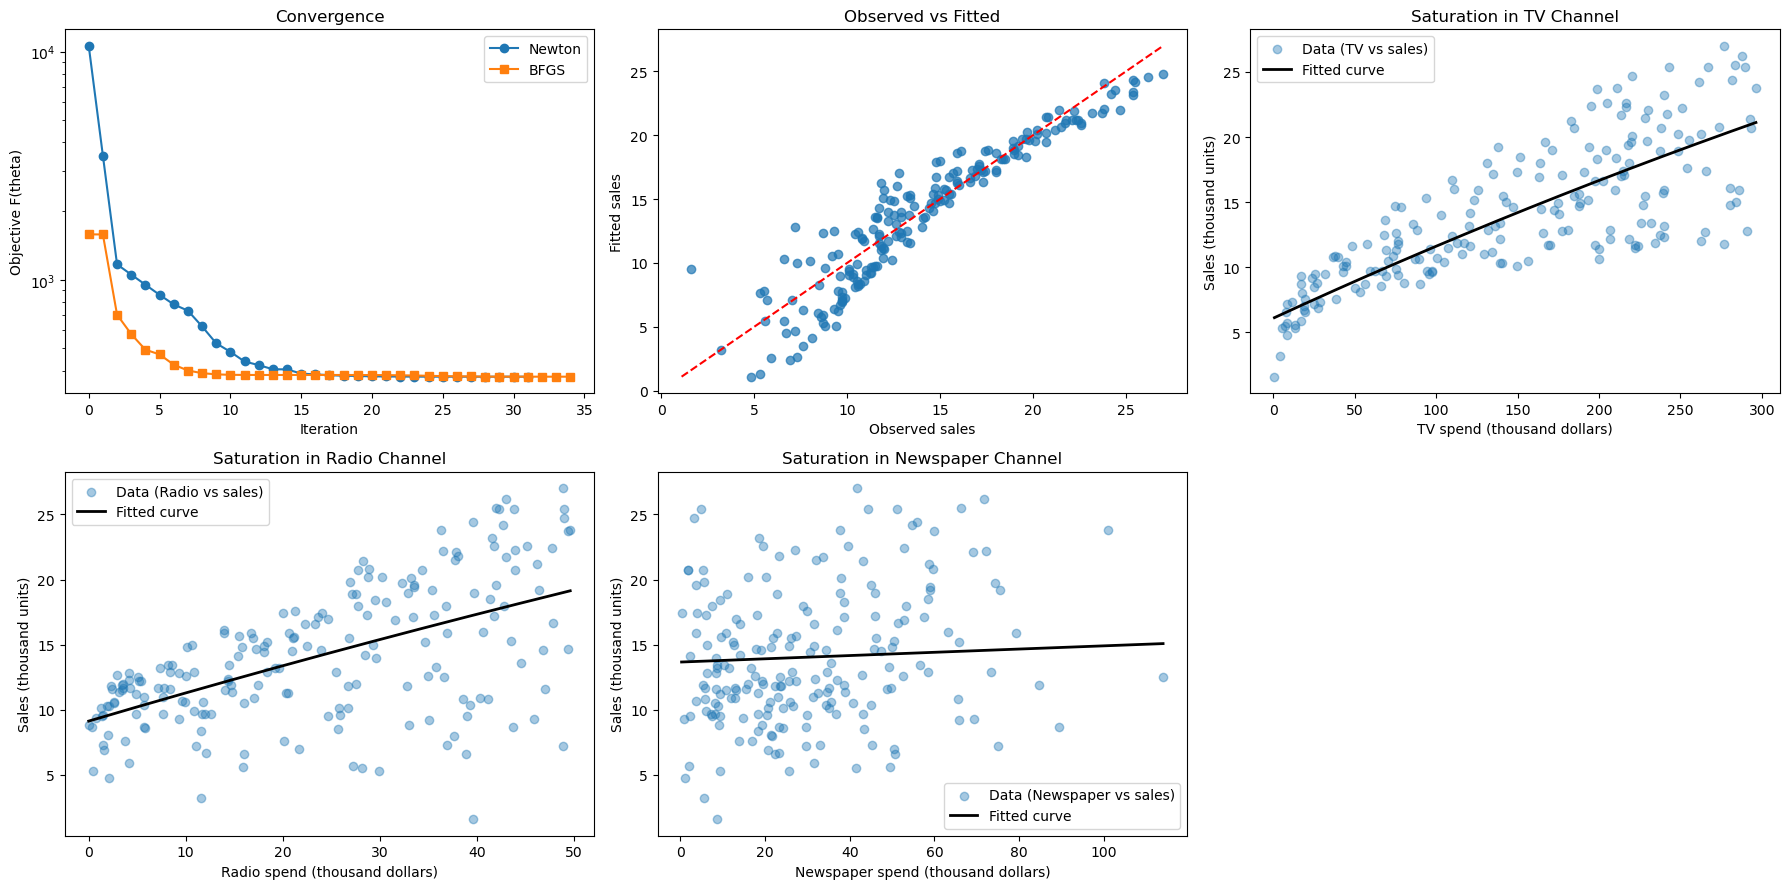

In [6]:
# Diagnostics: convergence + fit plots
fig, ax = plt.subplots(2, 3, figsize=(18, 9))
ax = ax.ravel()

# Convergence of objective
if len(hist_newton) > 0:
    ax[0].plot(hist_newton[:, 0], hist_newton[:, 1], marker="o", label="Newton")
if len(hist_bfgs) > 0:
    ax[0].plot(hist_bfgs[:, 0], hist_bfgs[:, 1], marker="s", label="BFGS")
ax[0].set_yscale("log")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Objective F(theta)")
ax[0].set_title("Convergence")
ax[0].legend()

# Observed vs fitted
ax[1].scatter(y, pred_best, alpha=0.7)
lo = min(y.min(), pred_best.min())
hi = max(y.max(), pred_best.max())
ax[1].plot([lo, hi], [lo, hi], "r--")
ax[1].set_xlabel("Observed sales")
ax[1].set_ylabel("Fitted sales")
ax[1].set_title("Observed vs Fitted")

# Channel response curves (other channels fixed at sample means)
x_mean = X.mean(axis=0)
channel_specs = [
    (0, "TV"),
    (1, "Radio"),
    (2, "Newspaper"),
]

for plot_idx, (col_idx, channel_name) in enumerate(channel_specs, start=2):
    spend_grid = np.linspace(X[:, col_idx].min(), X[:, col_idx].max(), 300)
    X_curve = np.tile(x_mean, (spend_grid.size, 1))
    X_curve[:, col_idx] = spend_grid
    pred_curve, _ = model(best_theta, X_curve)

    ax[plot_idx].scatter(X[:, col_idx], y, alpha=0.4, label=f"Data ({channel_name} vs sales)")
    ax[plot_idx].plot(spend_grid, pred_curve, color="black", linewidth=2, label="Fitted curve")
    ax[plot_idx].set_xlabel(f"{channel_name} spend (thousand dollars)")
    ax[plot_idx].set_ylabel("Sales (thousand units)")
    ax[plot_idx].set_title(f"Saturation in {channel_name} Channel")
    ax[plot_idx].legend()

ax[5].axis("off")

plt.tight_layout()
plt.show()
